To check if the model learned somthing from the MC data we recorded (stimulus did not run through)

In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
os.getcwd()


'/gpfs01/euler/User/ssuhai'

In [6]:
from omegaconf import DictConfig, OmegaConf
import hydra
from hydra.utils import instantiate
from hydra.core.config_store import ConfigStore
from hydra import compose, initialize
from IPython.display import display
import sys
import os
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np

### SET THIS PATH FROM THE CURRENT WORKING DIRECTORY TO THE REPO DIRECTORY
relative_repo_path = "GitRepos/simulation_closed_loop"

# appedn repo path to sys path
current_path = os.getcwd()
full_repo = os.path.join(current_path,relative_repo_path)
sys.path.append(full_repo)

In [7]:
from openretina.data_io.hoefling_2024.dataloaders import natmov_dataloaders_v2
from  thesis.code.analysis_closed_loop_experiments.utils_model_performance_on_online_data import (bring_pred_target_dict_to_array,plot_single_neuron_predicted_actual)

In [8]:
data_path_model_performance = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/analysis_closed_loop_experiments/model_performance_on_online_data"

### load data

In [22]:
# load test,val,train data
with open(os.path.join(data_path_model_performance, "test_corrs.pkl"), "rb") as f:
    test_corrs = pickle.load(f)
with open(os.path.join(data_path_model_performance, "val_corrs.pkl"), "rb") as f:
    val_corrs = pickle.load(f)
with open(os.path.join(data_path_model_performance, "train_corrs.pkl"), "rb") as f:
    train_corrs = pickle.load(f)

# load openretina comparison data
with open(os.path.join(data_path_model_performance,"test_corrs_comparison_sessionsession_1_ventral1_20200226.pkl"), "rb") as f:
    test_corrs_or = pickle.load(f)
with open(os.path.join(data_path_model_performance,"val_corrs_comparison_sessionsession_1_ventral1_20200226.pkl"), "rb") as f:
    val_corrs_or = pickle.load(f)
with open(os.path.join(data_path_model_performance,"train_corrs_comparison_sessionsession_1_ventral1_20200226.pkl"), "rb") as f:
    train_corrs_or = pickle.load(f)


# load pred targets
with open(os.path.join(data_path_model_performance, "test_pred_targets.pkl"), "rb") as f:
    test_pred_targes = pickle.load(f)

with open(os.path.join(data_path_model_performance, "val_pred_targets.pkl"), "rb") as f:
    val_pred_targes = pickle.load(f)  

with open(os.path.join(data_path_model_performance, "train_pred_targets.pkl"), "rb") as f:
    train_pred_targes = pickle.load(f)



In [12]:
np.mean([c for i,c in train_corrs_or.items()])

0.5272896789537952

In [13]:
np.mean([c for i,c in train_corrs.items()])

0.4208854737513677

In [14]:
np.mean([c for i,c in test_corrs.items()])

0.448801946911704

In [15]:
np.mean([c for i,c in test_corrs_or.items()])

0.5454962670263559

In [16]:
### plots

In [31]:
def plot_all(neuron_pred_targets_dict,axs = None):
    # bring in array format
    model_pred, response = bring_pred_target_dict_to_array(neuron_pred_targets_dict)

    n_neurons = model_pred.shape[0]
    if axs is None:
        fig, axs = plt.subplots(n_neurons,1, figsize=(10,n_neurons * 5))
    
    for neuron_idx in range(n_neurons):
        target_response = response[neuron_idx]
        predicted_response = model_pred[neuron_idx]
        plot_single_neuron_predicted_actual(target_response,predicted_response,ax=axs[neuron_idx])
    

Correlation between actual and predicted: 0.6155
Correlation between actual and predicted: 0.2026
Correlation between actual and predicted: 0.5441
Correlation between actual and predicted: 0.6469
Correlation between actual and predicted: 0.2129
Correlation between actual and predicted: 0.5955
Correlation between actual and predicted: 0.3240


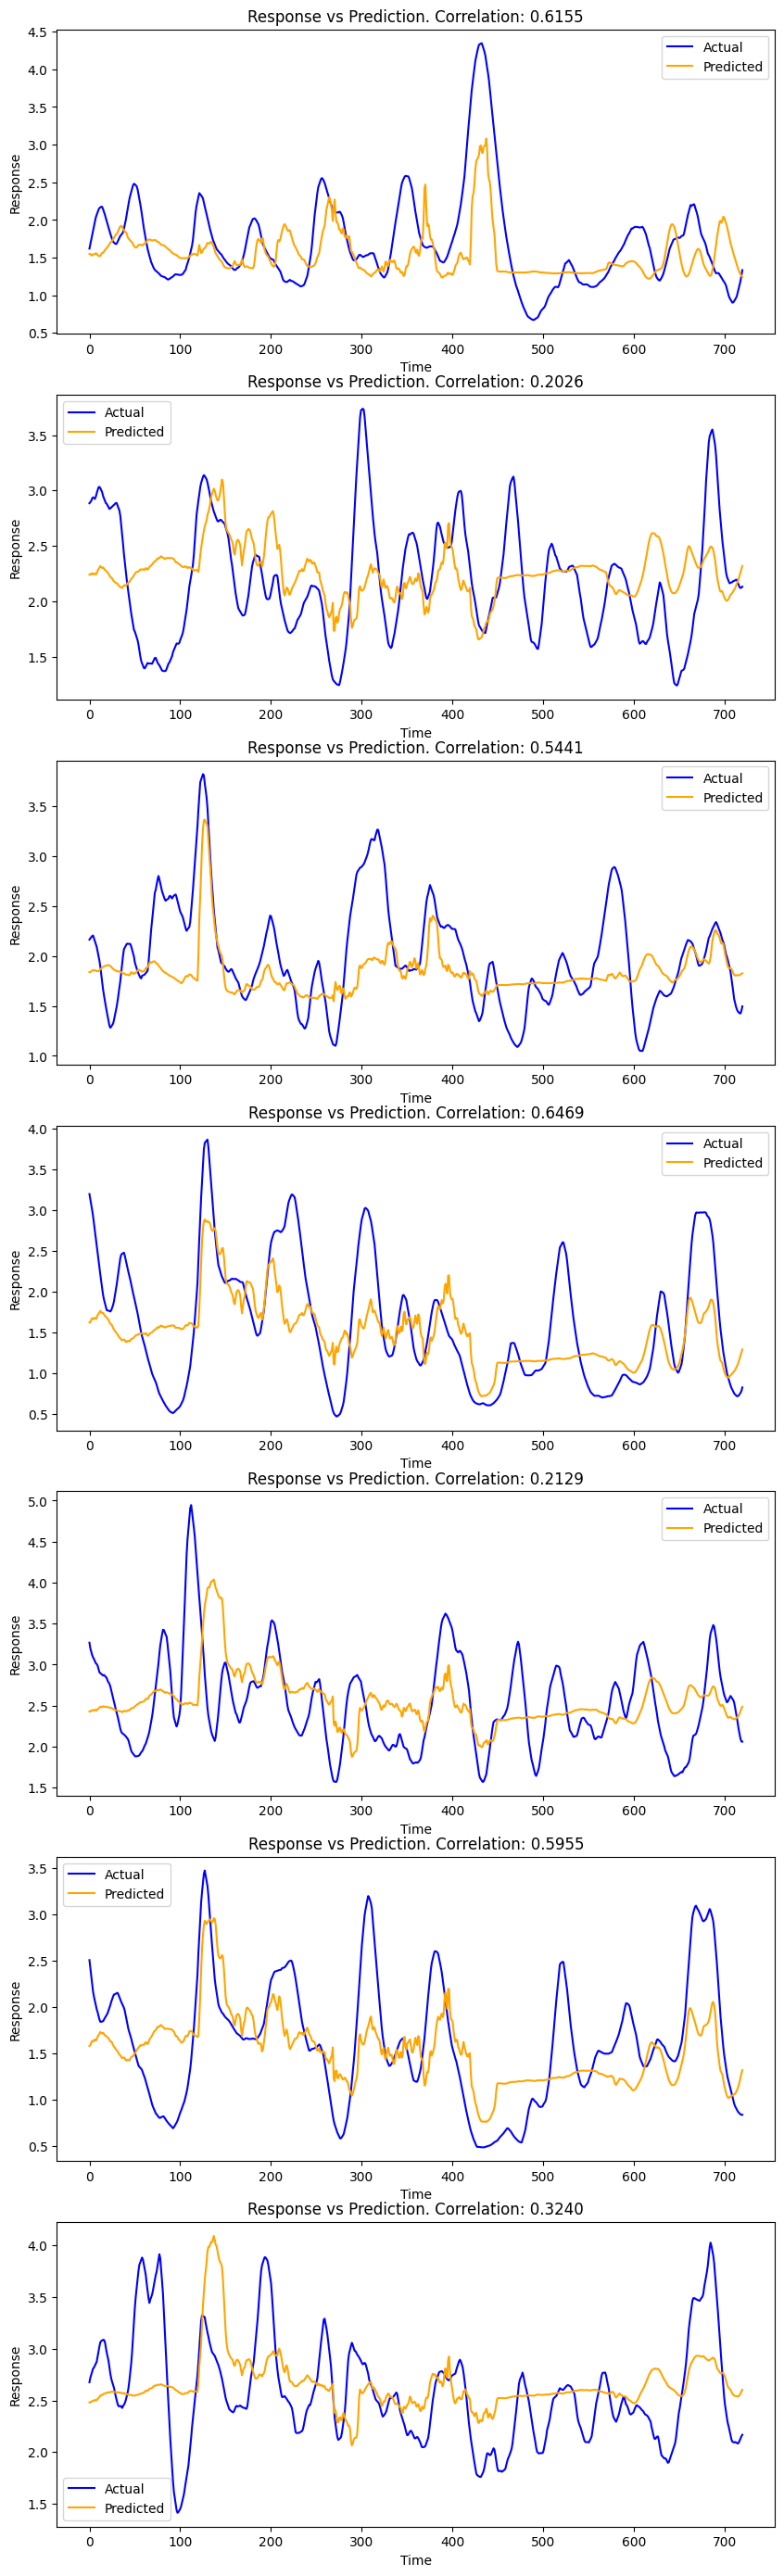

In [32]:
plot_all(neuron_pred_targets_dict = test_pred_targes)